# Kilter Grade Prediction — Exploratory Analysis

The **Kilter Board** is a standardised climbing board: each **climb** ("problem") is defined by the **holds** that may be used, together with the **role** of each hold
(start / hand / foot / finish) and the board **angle**.

There are different Kilter layouts and sizes. In this project, I will focus on the *16x12 — Original Layout* because it is the one at my home climbing gym!

The goal of the project is to train and test several supervised learning algorithms to predict the community grade of a Kilter climb. This might help setters grade new problems consistently, and later serve as a scoring function for a generative model of problems.

The data is extracted from the Kilter Board application database via the
[BoardLib](https://github.com/lemeryfertitta/BoardLib) utilities
(`data/raw/raw_kilter_data.db`).


In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent 
sys.path.insert(0, str(PROJECT_ROOT))

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.data_preparation import (
    get_layout_id, get_board_edges, parse_frames,
)

DB_PATH = PROJECT_ROOT / "data" / "raw" / "raw_kilter_data.db"


pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 4.5)

## 1. Dataset presentation

The BoardLib dump is a SQLite database. The tables relevant to us are:

| Table | Content | Used for |
|---|---|---|
| `layouts` | board layouts (Original, Homewall, ...) | scope restriction |
| `climbs` | one row per problem: `uuid`, `name`, `frames`, `angle`, bounding box | hold list |
| `climb_stats` | one row per problem: (`FK = climb_uuid`): `difficulty_average`, `quality_average`, `ascensionist_count` | **target** and scope restriction |
| `placements` | `placement_id -> hole_id` (a physical hold mounted on a hole) | geometry features|
| `holes` | `hole_id -> (x, y)` on the board grid | geometry features |

In [ ]:
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
)
print(f"{len(tables)} tables in the database")
display(tables.head(30))

for t in ["climbs", "climb_stats", "placements", "holes", "layouts"]:
    n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
    print(f"{t} : {n} rows")

31 tables in the database


,name
0,android_metadata
1,ascents
2,attempts
3,beta_links
4,bids
5,circuits
6,circuits_climbs
7,climb_cache_fields
8,climb_random_positions
9,climb_stats


climbs : 344504 rows
climb_stats : 348028 rows
placements : 3773 rows
holes : 3294 rows
layouts : 8 rows



As previously mentionned, we restrict the study to the following configuration :
- **layout = `Kilter Board Original`**
- **board size = `16x12`** (the full-size board)

Features from the `climbs` table include a bounding box (`edge_left`,
`edge_right`, `edge_bottom`, `edge_top`) so that we can filter problems that do not fit inside
the 16x12 frame. Theoretically, this is the biggest possible frame, but this filtering allows us to eliminate a few outliers.

In [ ]:
layouts = pd.read_sql_query("SELECT id, name FROM layouts", conn)
display(layouts)

TARGET_LAYOUT_NAME = "Kilter Board Original"
TARGET_BOARD_SIZE = "16x12"

# utilities from utils/data_preparation.py
layout_id = get_layout_id(conn, TARGET_LAYOUT_NAME)
edges = get_board_edges(TARGET_BOARD_SIZE)
print(f"Target layout '{TARGET_LAYOUT_NAME}' -> layout_id = {layout_id}")
print(f"Board size {TARGET_BOARD_SIZE} -> {edges}")

counts = {
    "all climbs": "SELECT COUNT(*) FROM climbs",
    "non-draft": "SELECT COUNT(*) FROM climbs WHERE is_draft = 0",
    "non-draft + layout": f"SELECT COUNT(*) FROM climbs WHERE is_draft = 0 AND layout_id = {layout_id}",
    "non-draft + layout + 16x12": f"""
        SELECT COUNT(*) FROM climbs
        WHERE is_draft = 0 AND layout_id = {layout_id}
          AND edge_left > {edges['edge_left']} AND edge_right < {edges['edge_right']}
          AND edge_bottom > {edges['edge_bottom']} AND edge_top < {edges['edge_top']}
    """,
}
for label, q in counts.items():
    print(f"{label:<28}: {pd.read_sql_query(q, conn).iloc[0, 0]:>8,}")

,id,name
0,1,Kilter Board Original
1,2,JUUL
2,3,Standard Medium
3,4,BKBBoard Level 1
4,6,Tycho Complete
5,7,Tycho 2020
6,8,Kilter Board Homewall
7,5,Spire


Target layout 'Kilter Board Original' -> layout_id = 1
Board size 16x12 -> {'edge_left': -24, 'edge_right': 168, 'edge_bottom': 0, 'edge_top': 156}
all climbs                  :  344,504
non-draft                   :  344,504
non-draft + layout          :  315,357
non-draft + layout + 16x12  :  314,668


The target variable is **`difficulty_average`** in table `climb_stats`: it is continuous, hence the
problem is treated as a **regression** rather than an ordinal classification. The prediction can be rounded back afterwards to recover the Font grade used in my home climbing gym.

In [ ]:
# Kilter internal difficulty scale -> Font / V-scale (restricted to our range)
GRADE_MAP = {
    10: "4a",  11: "4b",  12: "4c",  13: "5a",  14: "5b",  15: "5c",
    16: "6a",  17: "6a+", 18: "6b",  19: "6b+", 20: "6c",  21: "6c+",
    22: "7a",  23: "7a+", 24: "7b",  25: "7b+", 26: "7c",  27: "7c+",
    28: "8a",  29: "8a+", 30: "8b",  31: "8b+", 32: "8c",  33: "8c+",
    34: "9a",  35: "9a+", 36: "9b",  37: "9b+", 38: "9c",
}


def to_font(diff):
    """Round a continuous difficulty to the nearest Font grade label."""
    return GRADE_MAP.get(int(np.round(diff)), "?")

pd.DataFrame({"kilter_difficulty": list(GRADE_MAP), "font_grade": list(GRADE_MAP.values())}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
kilter_difficulty,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38
font_grade,4a,4b,4c,5a,5b,5c,6a,6a+,6b,6b+,6c,6c+,7a,7a+,7b,7b+,7c,7c+,8a,8a+,8b,8b+,8c,8c+,9a,9a+,9b,9b+,9c


A climb's holds are stored as a single string in `climbs.frames`, which is read as a sequence of `p<placement_id>r<role_id>` tokens.

The table `placements` maps each hold to a hole in the wall, and the table `holes` gives the corresponding (x, y) coordinates on the grid. The full procedure is summarized as:

frames --(parse)--> placement_id --(placements)--> hole_id --(holes)--> (x, y)

In [ ]:
example = pd.read_sql_query(
    f"""
    SELECT uuid, name, frames FROM climbs
    WHERE is_draft = 0 AND layout_id = {layout_id} AND LENGTH(frames) > 40
    LIMIT 1
    """, conn
).iloc[0]

print("name   :", example["name"])
print("frames :", example["frames"][:80], "...")

parsed = parse_frames(example["frames"])
print("\nparsed (placement_id, role_id):", parsed[:5], "...")

# placement ID -> hole ID -> (x, y)
ids = ",".join(str(p) for p, _ in parsed)
coords = pd.read_sql_query(
    f"""
    SELECT p.id AS placement_id, p.hole_id, h.x, h.y
    FROM placements p JOIN holes h ON h.id = p.hole_id
    WHERE p.id IN ({ids})
    """, conn
)
display(coords.head())
ROLE_MAP = {12: "start", 13: "hand", 14: "finish", 15: "foot"}
holds_xy = [
    (pid, *coords.set_index("placement_id").loc[pid, ["x", "y"]], ROLE_MAP.get(rid, "?"))
    for pid, rid in parsed if pid in set(coords["placement_id"])
]
holds_xy[:5]


name   : 4/26 Harder Than It Should Be
frames : p1145r12p1146r12p1149r13p1186r13p1201r13p1256r15p1267r13p1276r15p1307r13p1321r13 ...

parsed (placement_id, role_id): [(1145, 12), (1146, 12), (1149, 13), (1186, 13), (1201, 13)] ...


,placement_id,hole_id,x,y
0,1145,1294,40,40
1,1146,1341,48,40
2,1149,1408,72,40
3,1186,1509,96,56
4,1201,1451,80,64


[(1145, 40, 40, 'start'),
 (1146, 48, 40, 'start'),
 (1149, 72, 40, 'hand'),
 (1186, 96, 56, 'hand'),
 (1201, 80, 64, 'hand')]

From these spatial coordinates, we can recover a visualisation of the actual climb.
The helper `plot_climb()` from `utils/board_visuals.py` overlays the holds of a climb
on a picture of the 16x12 Original board, circling each hold with a colour that encodes
its role (start / hand / foot / finish).

Beyond being illustrative, this is a cheap sanity check: if the circles land on the hold, the whole `frames → placement_id → hole_id → (x, y)` chain is correct.

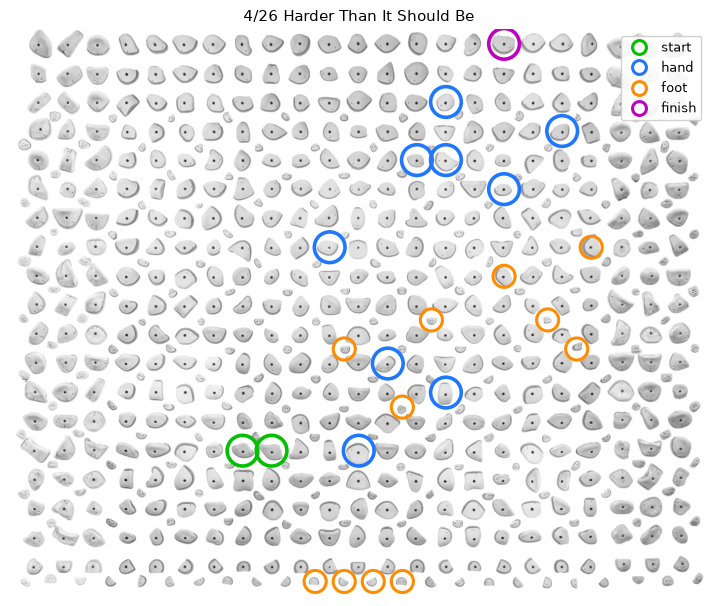

<Axes: title={'center': '4/26 Harder Than It Should Be'}>

In [ ]:
from utils.board_visuals import plot_climb

plot_climb(
    holds_xy,
    title=f"{example['name']}",
)

## 2. Data cleaning

The extraction and cleaning of the raw data (`utils/data_preparation.py`) applies several filters, in addition to the target layout and board size filters.

- drop duplicates on `(climb_uuid, angle)`,
- drop climbs with fewer than 3 holds,
- drop climbs containing unknown role IDs (values outside {12, 13, 14, 15},
  which appear on other layouts).

Before finalizing the dataset used for feature engineering, we inspect the
distributions of the key variables to motivate additional filtering choices:
grade range, minimum number of ascents, and minimum quality rating.

In [21]:

from utils.data_preparation import (
    load_raw_tables, merge_climbs_and_stats, build_hold_features, clean_dataset
)

conn = sqlite3.connect(DB_PATH)
layout_id = get_layout_id(conn, "Kilter Board Original")

climbs, stats = load_raw_tables(str(DB_PATH), layout_id, "16x12",
                               DIFF_MIN=10, DIFF_MAX = 38, 
                    ASCEND_MIN = 1, QUAL_MIN = 0)
df_raw = merge_climbs_and_stats(climbs, stats)
df_raw = build_hold_features(df_raw, conn)
df_raw = clean_dataset(df_raw)
conn.close()

print(f"Numbers of climbs after filtering: {len(df_raw):,}")
df_raw.head(3)

Data cleaning : dropped 30 climbs with invalid role IDs
Numbers of climbs after filtering: 113,400


,climb_uuid,angle,display_difficulty,difficulty_average,quality_average,ascensionist_count,name,frames,layout_id,is_draft,edge_left,edge_right,edge_bottom,edge_top,is_nomatch,holds,n_holds,placement_ids
0,065CAF74B4BC463B9D550750181F89D4,45,20.6667,20.6667,2.33333,3,Minimalism,p1234r12p1317r13p1387r14p1470r15,1,0,56,84,20,152,0,"[(1234, 72, 80, 12), (1317, 56, 120, 13), (138...",4,"[1234, 1317, 1387, 1470]"
1,074d41fcce3047d2bf1b2013a63e0454,70,20.0000,20.0000,2.00000,3,Feet Fetish,p1114r12p1131r12p1163r13p1195r13p1200r13p1204r...,1,0,32,104,24,152,0,"[(1114, 64, 24, 12), (1131, 64, 32, 12), (1163...",12,"[1114, 1131, 1163, 1195, 1200, 1204, 1217, 124..."
2,079F3EEDB0454FDF96380B280063D540,45,22.6667,22.6667,3.00000,3,The Reaper,p1161r12p1212r13p1218r15p1264r13p1285r13p1335r...,1,0,12,104,44,152,1,"[(1161, 32, 48, 12), (1212, 32, 72, 13), (1218...",9,"[1161, 1212, 1218, 1264, 1285, 1335, 1339, 139..."


### Distribution of climbs per grade


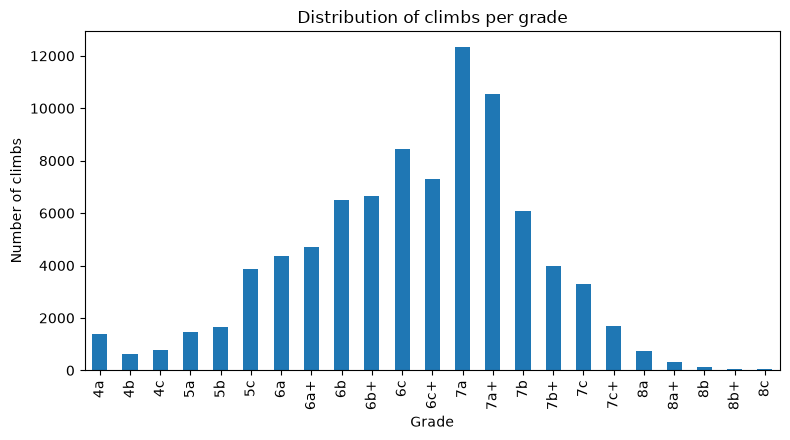

In [22]:
grade_counts = (
    df_raw["display_difficulty"]
    .map(GRADE_MAP)
    .value_counts()
    .reindex([GRADE_MAP[k] for k in sorted(GRADE_MAP)])
    .dropna()
)

ax = grade_counts.plot(kind="bar")
ax.set_xlabel("Grade")
ax.set_ylabel("Number of climbs")
ax.set_title("Distribution of climbs per grade")
plt.tight_layout()
plt.show()

Grades below `5c` and above `7c` are very sparsely represented, which means that `difficulty_average` is a noisy target for these grades. This motivates us to restrict the dataset to the **6a–7c** range (`difficulty_average` between
15 and 27 inclusive).

### Ascensionist count

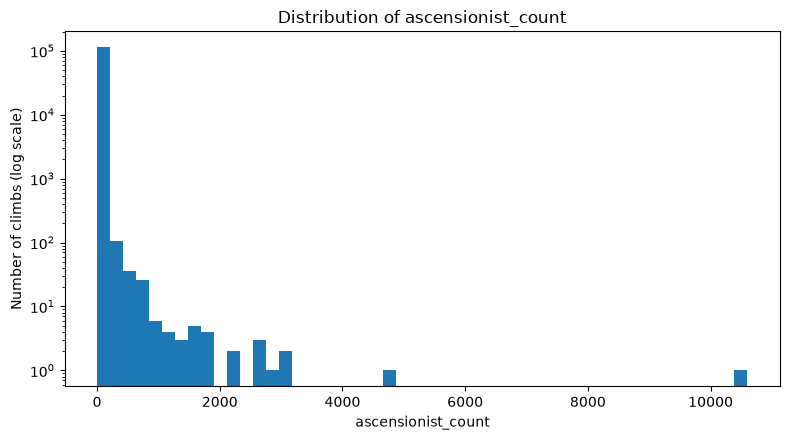

count    113400.00
mean          4.48
std          49.28
min           1.00
25%           1.00
50%           1.00
75%           3.00
max       10601.00
Name: ascensionist_count, dtype: float64

In [23]:
ax = plt.hist(df_raw["ascensionist_count"], bins=50)
ax = plt.gca()  # Get current axis
ax.set_yscale("log")
ax.set_xlabel("ascensionist_count")
ax.set_ylabel("Number of climbs (log scale)")
ax.set_title("Distribution of ascensionist_count")

plt.tight_layout()
plt.show()

df_raw["ascensionist_count"].describe().round(2)

We observe that a small number of extremely popular climbs dominate, while a large share of problems have been climbed only once. A `difficulty_average` computed from only 1–2 ascents is not a reliable community consensus as it can easily be a single climber's subjective opinion. It motivates us to filter out climbs with fewer than **5 ascents**.

### Quality average

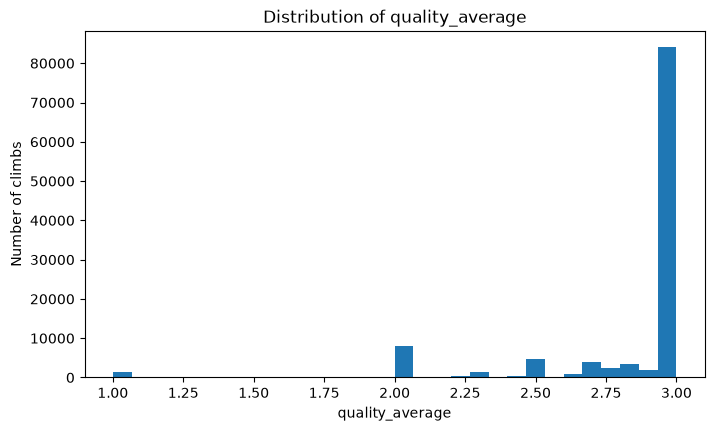

count    113400.00
mean          2.84
std           0.35
min           1.00
25%           2.89
50%           3.00
75%           3.00
max           3.00
Name: quality_average, dtype: float64

In [24]:
plt.hist(df_raw["quality_average"], bins=30)
plt.xlabel("quality_average")
plt.ylabel("Number of climbs")
plt.title("Distribution of quality_average")
plt.show()

df_raw["quality_average"].describe().round(2)

A large majority of climbs has `quality_average` above 2. We therefore filter out climbs with `quality_average < 2`, keeping only problems that the community considers at least minimally well-designed.

The cleaned dataset is the output of `utils/data_preparation.py`
(`data/processed/kilter_data_cleaned.csv`), which applies all the filters
described above.

In [25]:
conn.close()

CLEAN_CSV = PROJECT_ROOT / "data" / "processed" / "data_cleaned.csv"
df = pd.read_csv(CLEAN_CSV)

print(f"Numbers of climbs after grade and quality filtering: {len(df):,}")
display(df.head(3))
display(df[["angle", "n_holds", "difficulty_average",
            "quality_average", "ascensionist_count"]].describe().round(2))

Numbers of climbs after grade and quality filtering: 11,516


,climb_uuid,name,angle,layout_id,n_holds,holds,difficulty_average,quality_average,ascensionist_count,is_nomatch
0,167e313e708e42e39796b521ca6eeec7,pogo a gogo,45,1,11,"[(1097, 64, 16, 15), (1137, 112, 32, 15), (114...",21.0000,2.60000,5,0
1,F1DFFDBB7EB94D65AADAA43B7D817836,foot secret,0,1,14,"[(1076, 112, 8, 15), (1079, 88, 8, 15), (1137,...",20.8000,2.40000,5,0
2,A2A9C461F83645CCA53B91187A853FC8,grip,60,1,11,"[(1117, 88, 24, 15), (1131, 64, 32, 15), (1154...",26.8571,2.71429,7,0


,angle,n_holds,difficulty_average,quality_average,ascensionist_count
count,11516.00,11516.00,11516.00,11516.00,11516.00
mean,42.30,11.87,21.53,2.83,25.01
std,7.82,3.67,3.17,0.17,148.74
min,0.00,3.00,15.00,2.00,5.00
25%,40.00,9.00,19.00,2.75,5.00
50%,40.00,11.00,21.94,2.85,8.00
75%,50.00,14.00,23.90,3.00,14.00
max,70.00,65.00,27.00,3.00,10601.00


## 3. First analyses
### Influence of the angle

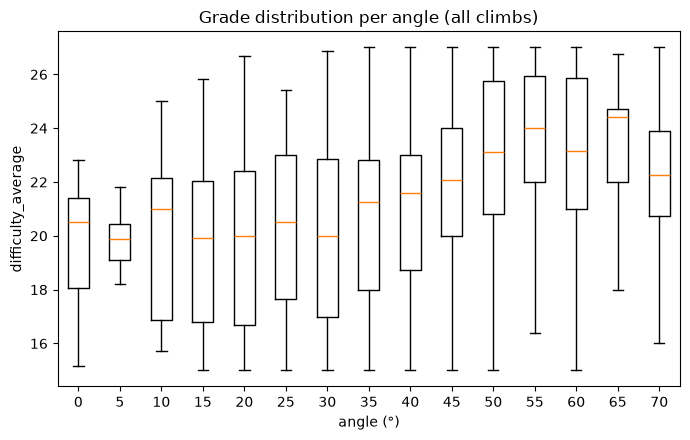

Pearson corr(angle, difficulty_average) = 0.254
angle
0       19
5        6
10      27
15      64
20     149
25     105
30     683
35     248
40    5754
45    1472
50    2475
55     152
60     269
65      14
70      79
Name: count, dtype: int64


In [26]:
fig, ax = plt.subplots(figsize=(7, 4.5))

angles = sorted(df["angle"].unique())
ax.boxplot([df.loc[df["angle"] == a, "difficulty_average"] for a in angles],
           tick_labels=angles, showfliers=False)
ax.set_xlabel("angle (°)")
ax.set_ylabel("difficulty_average")
ax.set_title("Grade distribution per angle (all climbs)")

plt.tight_layout()
plt.show()

print("Pearson corr(angle, difficulty_average) =",
      round(df["angle"].corr(df["difficulty_average"]), 3))
print(df["angle"].value_counts().sort_index())

The intuition that *climbs become harder as the wall steepens* seems to be justified, at least for angles between 30° and 40°, where the number of problems set is highest. Two comments:

1. The boxplot may be misleading: setters do not set the same kinds of problems at 20° and 50°, so part of the effect is a selection effect.
2. As the vast majority of problems are set between 30° and 50°, it could be justified to restrict the study to these values.

### Geometric features : influence of `avg_move_dist`

Since the cleaned dataset gives (x, y) positions for every hold in the climb, we can build several geometric features. This is part of the feature engineering presented in the next notebook. However, here we compute these geometric features to study the influence of `avg_move_dist` which is the average of the distance between each hand holds.

In [27]:
from utils.feature_engineering import ROLE_MAP, parse_holds, build_geometric_features
df["holds"] = df["holds"].apply(parse_holds)   # str -> list of [id, x, y, role_name]
geo = build_geometric_features(df)
geo.head()

,n_hand,n_foot,n_holds_total,board_width,board_height,hold_density,avg_move_dist,max_move_dist,std_move_dist,avg_foot_dist,max_foot_dist,std_foot_dist,foot_to_hand_ratio,hand_foot_dist,avg_consecutive_move,max_consecutive_move,std_consecutive_move,start_finish_dist,move_dist_x_angle,avg_consecutive_move_x_angle,max_foot_dist_x_angle
0,4,4,11,48,120,0.001910,46.621929,97.324200,22.814271,46.540798,61.188234,12.407823,0.571429,50.341284,24.258898,40.000000,11.697829,44.181444,1800.000000,1091.650406,2753.470537
1,4,8,14,64,144,0.001519,69.393431,121.852370,29.924656,50.016530,91.389277,21.194431,1.333333,37.666667,41.514322,53.665631,9.020036,40.000000,0.000000,0.000000,0.000000
2,3,5,11,80,128,0.001074,58.215669,118.928550,27.611638,44.052458,75.894664,16.928703,0.833333,48.234243,33.806384,45.254834,13.248712,59.059292,2715.290040,2028.383060,4553.679831
3,6,1,10,104,136,0.000707,73.251496,164.924225,41.989370,0.000000,0.000000,0.000000,0.111111,61.359093,25.855659,32.984845,5.956918,166.469216,989.545350,775.669783,0.000000
4,6,5,13,88,148,0.000998,59.283521,120.000000,29.311746,66.527138,113.701363,29.334962,0.625000,55.526030,31.553783,45.607017,10.074801,80.000000,1596.245595,1104.382419,3979.547713


corr(avg_move_dist, difficulty) = 0.392


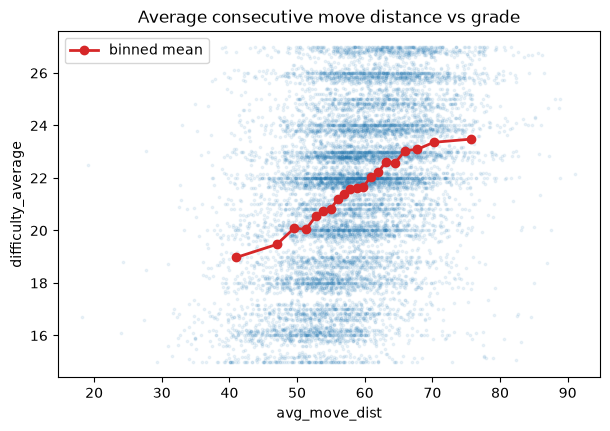

In [28]:
df_geo = pd.concat([df[["difficulty_average", "angle", "n_holds"]], geo], axis=1)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(df_geo["avg_move_dist"], df_geo["difficulty_average"],
                s=3, alpha=0.08, color="tab:blue")
# Bin move distances into quantiles to make the trend easier to see.
bins = pd.qcut(df_geo["avg_move_dist"], 20, duplicates="drop")
binned = df_geo.groupby(bins, observed=True).agg(
    x=("avg_move_dist", "mean"), y=("difficulty_average", "mean"))
ax.plot(binned["x"], binned["y"], color="tab:red", marker="o", lw=2,
             label="binned mean")
ax.set_xlabel("avg_move_dist"); ax.set_ylabel("difficulty_average")
ax.set_title("Average consecutive move distance vs grade")
ax.legend()

print("corr(avg_move_dist, difficulty) =",
      round(df_geo["avg_move_dist"].corr(df_geo["difficulty_average"]), 3))

This feature has a even higher correlation coefficient than `angle`. This is all very intuitive: the greater the distance betwenn each consecutive moves, the harder the climb. 